In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
import joblib

plt.rcParams['font.family'] = 'DejaVu Sans'

In [2]:
data = pd.read_csv("../results/outputs/scaled.csv")
target_column = 'Status'
X = data.drop(columns=[target_column])
y = data[target_column]

print(f"✅ Dataset loaded: {X.shape[0]} samples, {X.shape[1]} features.")
print("Class distribution:\n", y.value_counts())

✅ Dataset loaded: 15000 samples, 20 features.
Class distribution:
 Status
0    5000
1    5000
2    5000
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4]:
base_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)
base_rf.fit(X_train, y_train)
base_pred = base_rf.predict(X_test)

In [5]:
def safe_auc(model, X_test, y_test):
    classes = np.unique(y_test)
    Y = label_binarize(y_test, classes=classes)
    proba = model.predict_proba(X_test)
    return roc_auc_score(Y, proba, multi_class='ovr', average='macro')


In [6]:
base_metrics = {
    "Accuracy": accuracy_score(y_test, base_pred),
    "Precision": precision_score(y_test, base_pred, average='weighted'),
    "Recall": recall_score(y_test, base_pred, average='weighted'),
    "F1 Score": f1_score(y_test, base_pred, average='weighted'),
    "AUC": safe_auc(base_rf, X_test, y_test)
}

print("\n=== 🌲 Base Random Forest Results ===")
print(classification_report(y_test, base_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, base_pred))
print("Base Model F1 Score:", round(base_metrics["F1 Score"], 4))


=== 🌲 Base Random Forest Results ===
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1000
           1       1.00      0.99      0.99      1000
           2       0.98      0.97      0.97      1000

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000

Confusion Matrix:
 [[982   1  17]
 [  3 990   7]
 [ 26   1 973]]
Base Model F1 Score: 0.9817


In [7]:
param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid=param_grid,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

best_grid = grid_search.best_estimator_
print("\n🔍 Best Parameters (Grid Search):", grid_search.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

🔍 Best Parameters (Grid Search): {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [8]:
param_dist = {
    'n_estimators': randint(200, 600),
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'bootstrap': [True, False]
}

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=30,
    cv=skf,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    random_state=42
)
random_search.fit(X_train, y_train)

best_random = random_search.best_estimator_
print("\n🎲 Best Parameters (Randomized Search):", random_search.best_params_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits

🎲 Best Parameters (Randomized Search): {'bootstrap': False, 'max_depth': 40, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 291}


In [9]:
def evaluate_model(model, X_test, y_test, label):
    pred = model.predict(X_test)
    metrics = {
        "Model": label,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average='weighted'),
        "Recall": recall_score(y_test, pred, average='weighted'),
        "F1 Score": f1_score(y_test, pred, average='weighted'),
        "AUC": safe_auc(model, X_test, y_test)
    }
    return metrics

In [10]:
results = [
    evaluate_model(base_rf, X_test, y_test, "Base RF"),
    evaluate_model(best_grid, X_test, y_test, "GridSearch RF"),
    evaluate_model(best_random, X_test, y_test, "RandomSearch RF")
]

results_df = pd.DataFrame(results)
print("\n=== 📊 Model Comparison Results ===")
print(results_df)



=== 📊 Model Comparison Results ===
             Model  Accuracy  Precision    Recall  F1 Score       AUC
0          Base RF  0.981667   0.981742  0.981667  0.981689  0.999031
1    GridSearch RF  0.984333   0.984377  0.984333  0.984345  0.999175
2  RandomSearch RF  0.980667   0.980762  0.980667  0.980687  0.999020


In [11]:
cv_accs = {
    'Base RF': cross_val_score(base_rf, X_train, y_train, cv=skf, scoring='f1_weighted').mean(),
    'GridSearch RF': cross_val_score(best_grid, X_train, y_train, cv=skf, scoring='f1_weighted').mean(),
    'RandomSearch RF': cross_val_score(best_random, X_train, y_train, cv=skf, scoring='f1_weighted').mean()
}

cv_df = pd.DataFrame({
    'Model': list(cv_accs.keys()),
    'CV F1 Score': list(cv_accs.values())
})
print("\n=== 🧩 Cross-Validation F1 Score Comparison ===")
print(cv_df)


=== 🧩 Cross-Validation F1 Score Comparison ===
             Model  CV F1 Score
0          Base RF     0.983940
1    GridSearch RF     0.985848
2  RandomSearch RF     0.984100


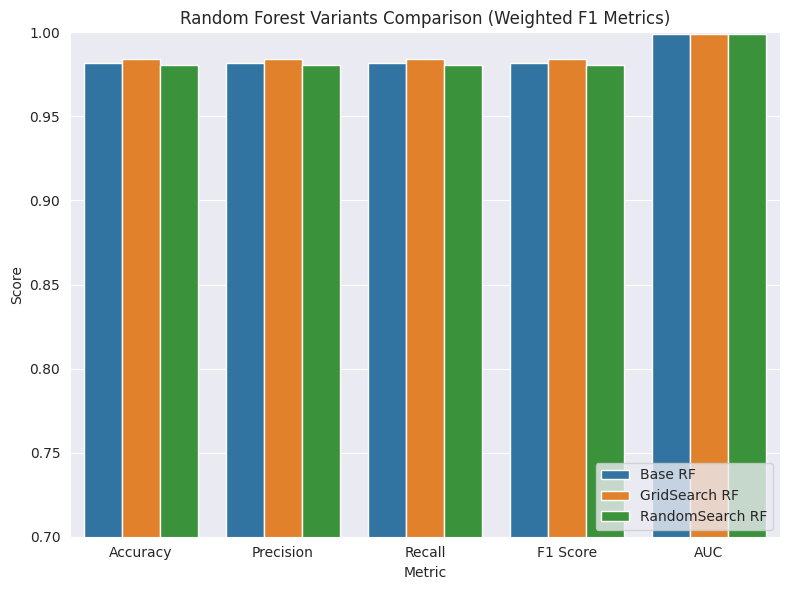

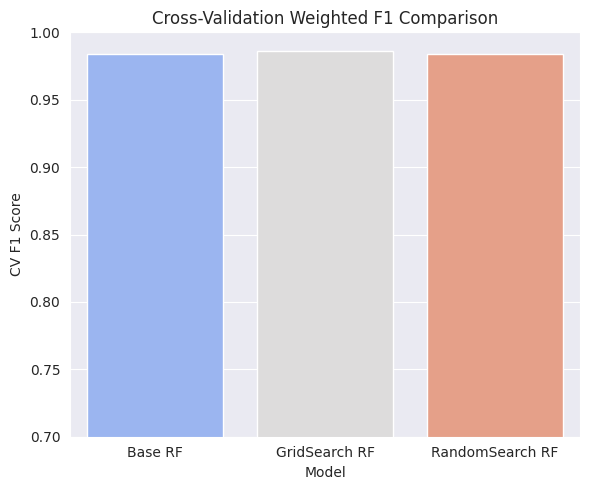

In [12]:
plt.figure(figsize=(8, 6))
results_df_melt = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(data=results_df_melt, x='Metric', y='Score', hue='Model')
plt.title("Random Forest Variants Comparison (Weighted F1 Metrics)")
plt.ylim(0.7, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
sns.barplot(data=cv_df, x='Model', y='CV F1 Score', hue='Model', palette='coolwarm', legend=False)
plt.title("Cross-Validation Weighted F1 Comparison")
plt.ylim(0.7, 1.0)
plt.tight_layout()
plt.show()

In [13]:
best_overall = max(results, key=lambda x: x['F1 Score'])
if best_overall['Model'] == "Base RF":
    final_model = base_rf
elif best_overall['Model'] == "GridSearch RF":
    final_model = best_grid
else:
    final_model = best_random

joblib.dump(final_model, "best_random_forest_tuned.pkl")
print(f"\n✅ Best Performing Model ({best_overall['Model']}) saved as best_random_forest_tuned.pkl")


✅ Best Performing Model (GridSearch RF) saved as best_random_forest_tuned.pkl


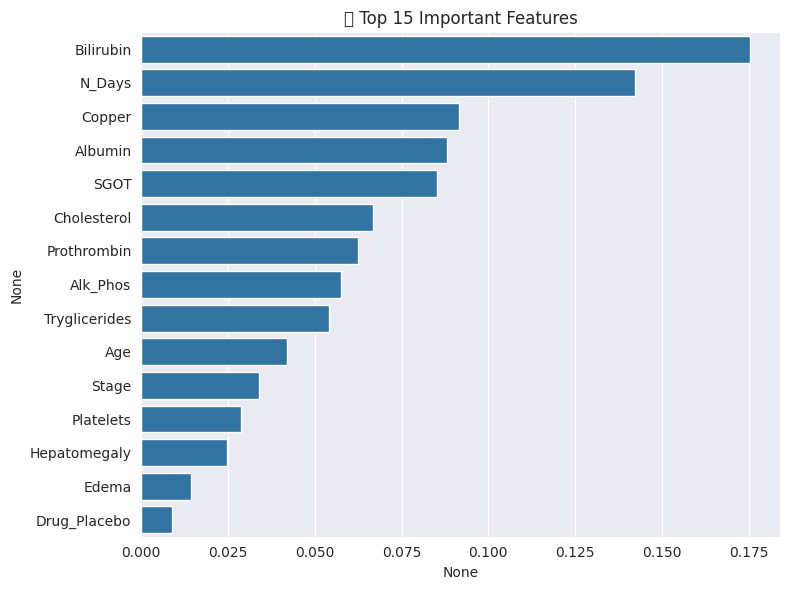


=== Training Complete ✅ ===
All warnings suppressed. Model and plots generated successfully.


In [14]:
importances = pd.Series(final_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.head(15), y=importances.head(15).index)
plt.title("🔥 Top 15 Important Features")
plt.tight_layout()
plt.show()

print("\n=== Training Complete ✅ ===")
print("All warnings suppressed. Model and plots generated successfully.")

